# Chronic Kidney Disease Classification

Compare classifiers on 400 patient records while retaining incomplete observations. CKD is the positive class (`1`).

## 1. Imports

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

## 2. Data Inspection and Cleaning

Inspect the schema and standardize numeric fields and labels before splitting the data.

In [2]:
data_path = Path("kidney_disease .csv")
if not data_path.exists():
    data_path = Path("..") / data_path

df = pd.read_csv(data_path)
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
df.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [5]:
df.drop(columns="id").duplicated().sum()

np.int64(0)

### Convert Numeric Fields

Convert `pcv` (packed cell volume), `wc` (white blood cell count) and `rc` (red blood cell count) to numeric types. Invalid entries become missing values; remove the identifier from the predictors.

In [6]:
for column in ["pcv", "wc", "rc"]:
    df[column] = pd.to_numeric(df[column], errors="coerce").astype(float)

In [7]:
df = df.drop(labels="id", axis=1)

### Clean Categorical Labels

Strip whitespace from categorical predictors and the target so equivalent labels are treated consistently.

In [8]:
for column in df.select_dtypes(include=["object", "category"]).columns:
    df[column] = df[column].str.strip()

df.select_dtypes(include="object").nunique()

rbc               2
pc                2
pcc               2
ba                2
htn               2
dm                2
cad               2
appet             2
pe                2
ane               2
classification    2
dtype: int64

In [9]:
X = df.drop(labels="classification", axis=1)
y = df["classification"].map({"notckd": 0, "ckd": 1})

In [10]:
assert y.notna().all(), "The target must contain only ckd or notckd."
y.value_counts().rename(index={0: "Not CKD", 1: "CKD"})

classification
CKD        250
Not CKD    150
Name: count, dtype: int64

### Feature Groups

The [UCI data dictionary](https://archive.ics.uci.edu/dataset/336/chronic) defines three numeric-coded categorical predictors:

- `sg`: specific gravity, recorded at five levels (1.005, 1.010, 1.015, 1.020, 1.025).
- `al`: urine albumin category, from 0 to 5.
- `su`: urine sugar category, from 0 to 5.

These existing columns form `discrete_cols` and receive mode imputation and one-hot encoding. The remaining numeric columns use mean/median imputation; text categories form `cat_cols`.

In [11]:
discrete_cols = ["sg", "al", "su"]
num_cols = X.select_dtypes(include="number").columns.difference(discrete_cols).tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

## 3. Train-Test Split

Reserve a stratified 20% test set and use the remaining 80% for exploration and cross-validation. Stratification preserves the class proportions.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. Exploratory Data Analysis

Inspect training distributions and missingness to understand the data used for model development. Boxplots highlight values for closer inspection.

In [13]:
X_train.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
count,312.000000,309.000000,279.000000,280.000000,278.000000,282.000000,301.000000,304.000000,245.000000,244.000000,277.000000,262.000000,236.000000,215.000000
mean,51.086538,76.763754,1.017384,1.003571,0.388489,145.053191,57.445847,3.148355,137.042857,4.352459,12.518773,38.675573,8403.813559,4.716279
std,17.156989,14.183830,0.005655,1.340032,1.033803,75.856678,49.632905,6.049149,11.104718,0.756178,2.972667,8.992850,3084.654240,1.020704
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,100.000000,27.000000,0.900000,135.000000,3.800000,10.400000,32.000000,6300.000000,3.900000
50%,54.000000,80.000000,1.020000,0.000000,0.000000,120.500000,42.000000,1.200000,138.000000,4.300000,12.600000,40.000000,8100.000000,4.800000
75%,64.000000,80.000000,1.020000,2.000000,0.000000,156.000000,66.000000,2.900000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.500000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,322.000000,76.000000,150.000000,7.600000,17.800000,54.000000,26400.000000,6.500000


### Outlier Handling

All patient records are retained. Statistical outliers are inspected rather than automatically removed, because extreme measurements may represent disease severity. Numerical values are kept without capping; non-numeric entries in numeric fields are treated as missing.

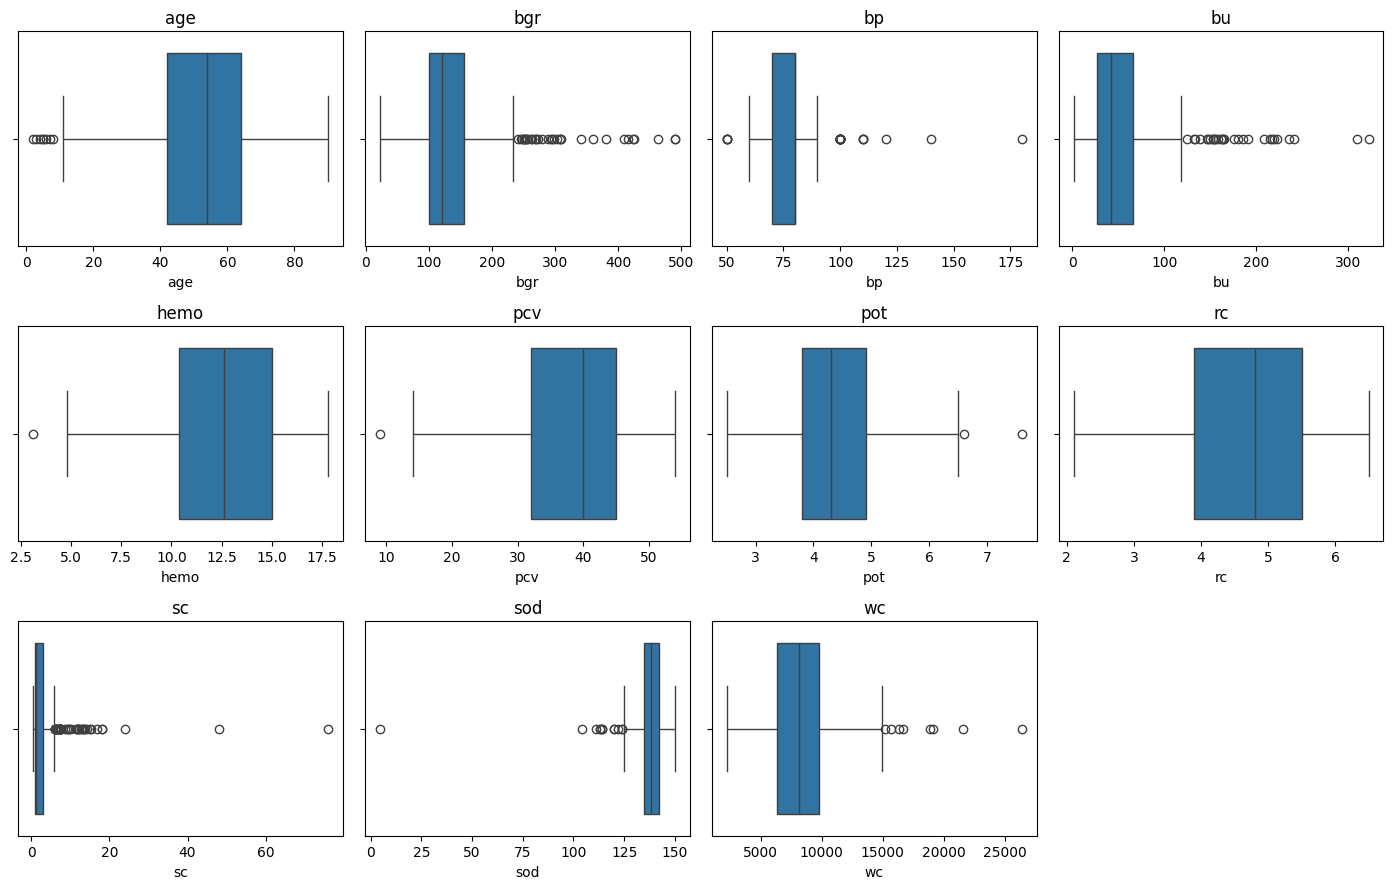

In [ ]:
def visualize_outliers(data):
    """Inspect continuous predictors without changing observations."""
    fig, axes = plt.subplots(3, 4, figsize=(14, 9))
    for column, ax in zip(num_cols, axes.flat):
        sns.boxplot(x=data[column], ax=ax)
        ax.set_title(column)
    for ax in axes.flat[len(num_cols) :]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


visualize_outliers(X_train)

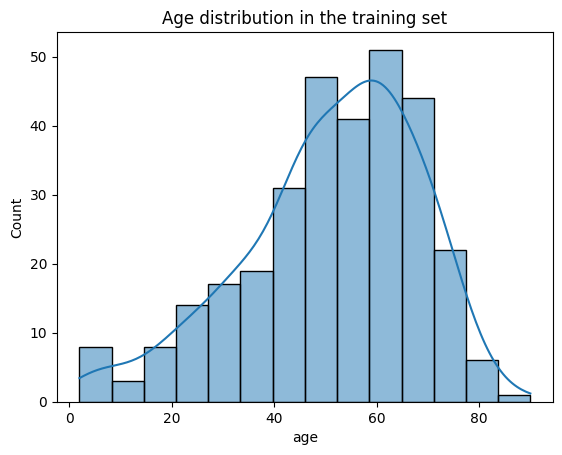

Age skewness: -0.67


In [15]:
sns.histplot(data=X_train, x="age", kde=True)
plt.title("Age distribution in the training set")
plt.show()
print(f"Age skewness: {X_train['age'].skew():.2f}")

### Numerical Imputation

Use the mean when absolute skewness is below 0.5 and the median otherwise. The median reduces sensitivity to asymmetric distributions. Skewness is measured separately within each training fold.

### Missing Values by Feature

In [16]:
missing_summary = pd.DataFrame(
    {
        "Missing count": X_train.isna().sum(),
        "Missing (%)": X_train.isna().mean().mul(100).round(2),
    }
)
missing_summary.sort_values("Missing (%)", ascending=False)

,Missing count,Missing (%)
rbc,126,39.38
rc,105,32.81
wc,84,26.25
pot,76,23.75
sod,75,23.44
pcv,58,18.12
pc,54,16.88
hemo,43,13.44
su,42,13.12
sg,41,12.81


Use `unknown` for missing `rbc` values to preserve the distinction between unrecorded and observed results. This feature was missing in 39% of the original records. Fill other categorical predictors with their training mode.

### Missing Values by Record

In [17]:
row_missing_fraction = X_train.isna().mean(axis=1)
pd.crosstab(
    y_train.map({0: "Not CKD", 1: "CKD"}),
    row_missing_fraction.gt(0.25).map({False: "At most 25%", True: "Over 25%"}),
    rownames=["Class"],
    colnames=["Missing predictors"],
)

Missing predictors,At most 25%,Over 25%
Class,,
CKD,155,45
Not CKD,120,0


Retain all records because the dataset is small and rows with substantial missingness are concentrated in the CKD class. Imputation preserves their observed information without selectively reducing that class.

### Feature Correlations

Inspect associations with CKD using the training data. Binary labels are encoded for this plot, and each correlation uses the available observation pairs.

In [18]:
binary_maps = {
    "htn": {"no": 0, "yes": 1},
    "dm": {"no": 0, "yes": 1},
    "cad": {"no": 0, "yes": 1},
    "pe": {"no": 0, "yes": 1},
    "ane": {"no": 0, "yes": 1},
    "pcc": {"notpresent": 0, "present": 1},
    "ba": {"notpresent": 0, "present": 1},
    "rbc": {"normal": 0, "abnormal": 1},
    "pc": {"normal": 0, "abnormal": 1},
    "appet": {"good": 0, "poor": 1},
}

df_corr = X_train.assign(classification=y_train)

for col, mapping in binary_maps.items():
    df_corr[col] = df_corr[col].map(mapping)

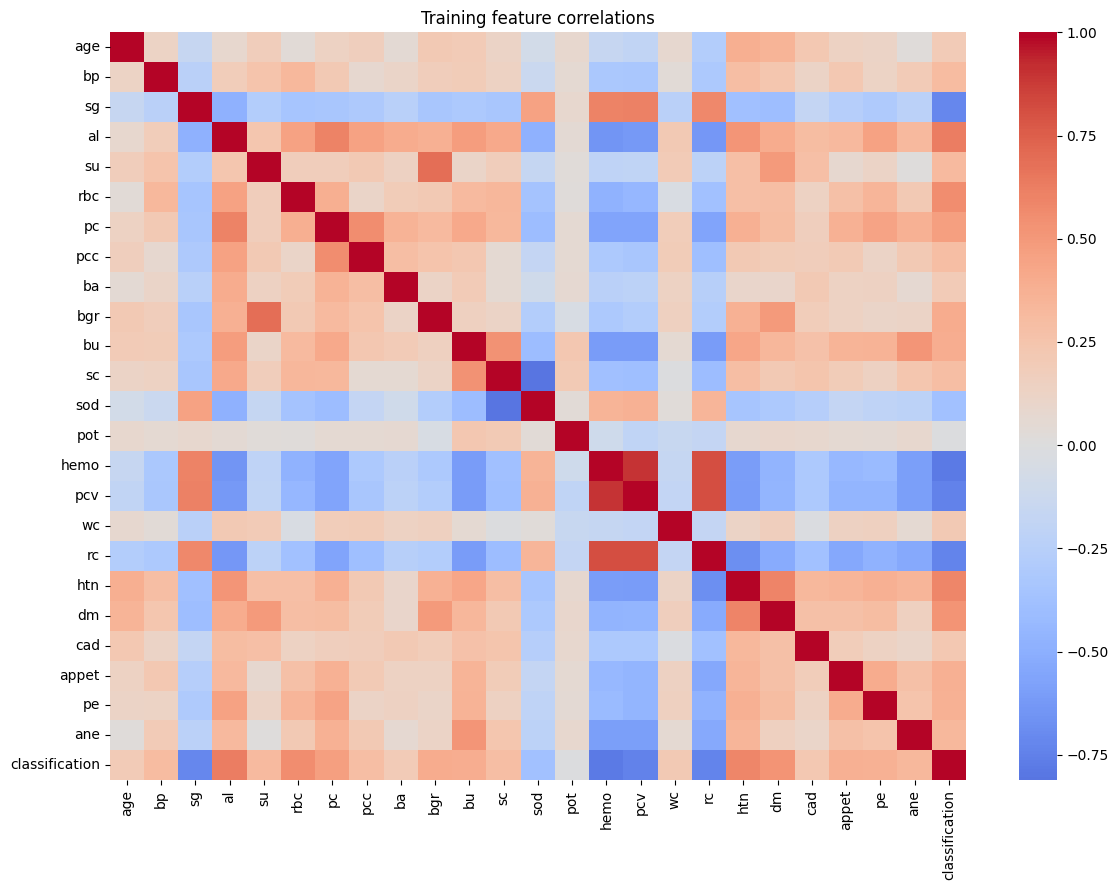

In [19]:
corr = df_corr.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Training feature correlations")
plt.tight_layout()
plt.show()

In [20]:
corr["classification"].drop("classification").abs().sort_values(ascending=False)

hemo     0.781314
pcv      0.747561
rc       0.738692
sg       0.723542
al       0.626350
htn      0.586031
rbc      0.557859
dm       0.527836
pc       0.475085
bgr      0.400226
bu       0.393496
appet    0.378868
sod      0.375698
pe       0.363624
ane      0.328605
su       0.316212
bp       0.309571
sc       0.293550
pcc      0.285763
cad      0.224369
wc       0.214620
age      0.198116
ba       0.197963
pot      0.007259
Name: classification, dtype: float64

## 5. Preprocessing Pipeline

### Select Mean or Median Within Each Fold

The column selectors run when the preprocessor is fitted, so each fold determines its own imputation strategy from its training observations. Constant columns use the median.

In [484]:
def mean_columns(data):
    skewness = data[num_cols].skew()
    return skewness.index[skewness.abs() < 0.5].tolist()


def median_columns(data):
    return [column for column in num_cols if column not in mean_columns(data)]


mean_columns(X)

['hemo', 'pcv', 'rc']

In [22]:
unknown_cols = ["rbc"]
most_frequent_cols = [column for column in cat_cols if column not in unknown_cols]

### Impute, Scale and Encode

Standardize continuous predictors after imputation. Treat `sg`, `al` and `su` as discrete categories, using mode imputation and one-hot encoding. Fit all learned transformations within the training pipeline.

In [23]:
num_mean_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="mean", keep_empty_features=True)),
        ("scaler", StandardScaler()),
    ]
)
num_median_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
        ("scaler", StandardScaler()),
    ]
)
most_frequent_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent", keep_empty_features=True)),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)
constant_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("mean", num_mean_pipeline, mean_columns),
        ("median", num_median_pipeline, median_columns),
        ("categorical", most_frequent_pipeline, most_frequent_cols),
        ("discrete", clone(most_frequent_pipeline), discrete_cols),
        ("unknown", constant_pipeline, unknown_cols),
    ]
)


def build_pipeline(model):
    # Fresh, unfitted copies keep each model pipeline independent.
    return Pipeline(
        [
            ("preprocessing", clone(preprocessor)),
            ("model", clone(model)),
        ]
    )

## 6. Candidate Models

Compare logistic regression, a support vector machine and tree-based classifiers using the same preprocessing and validation folds.

In [474]:
models = {
    "SVM": SVC(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=50, max_depth=10, random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
    ),
}

## 7. Cross-Validation and Model Selection

Compare mean scores across five stratified folds. SVM is selected by sorting on F1 and then recall; ties preserve the candidate order.

In [475]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_cv = []

for name, model in models.items():
    cv_results = cross_validate(
        build_pipeline(model),
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        error_score="raise",
    )
    results_cv.append(
        {
            "Model": name,
            "Accuracy": cv_results["test_accuracy"].mean(),
            "Precision": cv_results["test_precision"].mean(),
            "Recall": cv_results["test_recall"].mean(),
            "F1": cv_results["test_f1"].mean(),
        }
    )

In [481]:
results_cv_df = (
    pd.DataFrame(results_cv)
    .sort_values(["F1", "Recall"], ascending=False, kind="stable")
    .reset_index(drop=True)
)

best_model_name = results_cv_df.iloc[0, 0]
display(results_cv_df.round(3))
print(f"Selected model: {best_model_name}")

,Model,Accuracy,Precision,Recall,F1
0,SVM,1.000,1.000,1.000,1.000
1,LogisticRegression,1.000,1.000,1.000,1.000
2,RandomForest,0.991,0.990,0.995,0.993
3,CatBoost,0.988,0.995,0.985,0.990
4,XGBoost,0.981,0.976,0.995,0.985
5,GradientBoosting,0.978,0.976,0.990,0.983
6,DecisionTree,0.959,0.975,0.960,0.967


Selected model: SVM


## 8. Test Evaluation

Refit the selected SVM on all training records and evaluate it using its default predict method. The confusion matrix shows false positives and missed CKD cases.

,Model,Accuracy,Precision,Recall,F1
0,SVM,1.0,1.0,1.0,1.0


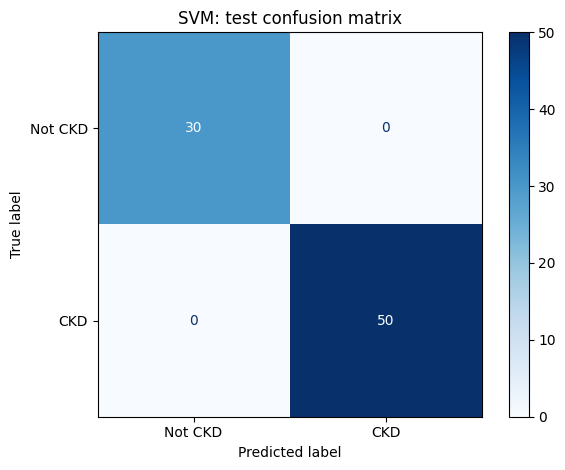

In [482]:
best_pipeline = build_pipeline(models[best_model_name])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

results_df = pd.DataFrame(
    [
        {
            "Model": best_model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
        }
    ]
)
display(results_df.round(4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=[0, 1],
    display_labels=["Not CKD", "CKD"],
    cmap="Blues",
)
plt.title(f"{best_model_name}: test confusion matrix")
plt.tight_layout()
plt.show()